<h1 style="text-align:center; font-size:42px; margin-top:40px;">
Collecte de Données d’Emploi via une API REST
</h1>


## 1. Contexte et objectif

#### *Collecte de données d’emploi via une API*

Ce notebook s’inscrit dans un pipeline d’analyse multi-sources.  
L’objectif est d’intégrer des données issues d’une API REST locale dans un flux de traitement visant à analyser la dynamique du marché de l'emploi tech.

Je m’appuie ici sur une API Flask qui expose un jeu d’offres d’emploi au format JSON.  
Ce service joue le rôle d’un **fournisseur de données externe**, comme un backend interne ou un microservice exposé par une équipe IT.

Le but du notebook :
- interroger l’API de manière paramétrée,
- extraire des sous-ensembles pertinents (compétences, villes),
- agréger les résultats,
- produire un fichier Excel structuré pour les étapes d’analyse suivantes.


## 2. API utilisée

L’API REST utilisée ici est un service Flask fourni dans un atelier Coursera. Je l’emploie comme source externe afin de démontrer l’intégration d’un endpoint API dans un pipeline analytique moderne. L’ensemble du traitement, de la structuration et des analyses réalisées dans ce projet sont de ma propre conception.

Principaux endpoints :
- `GET /data/all` : retourne l’ensemble des offres.
- `GET /data` + paramètres : retourne un sous-ensemble filtré.

Paramètres courants :
- `Location`
- `Key Skills`
- `Industry`
- `Role`

Le service permet d’interroger le jeu d’offres selon différents critères et d’obtenir uniquement les enregistrements pertinents pour l’analyse.


## 3. Lancement du service API
Avant d’interroger les données, je démarre l’API Flask localement (src/Jobs_API).

Une fois en exécution, les endpoints deviennent accessibles :

In [20]:
api_url="http://127.0.0.1:5000/data"

## 4. Objectif de la collecte

### Deux axes d’analyse :

#### A. Analyse géographique 
Extraction du nombre de postes disponibles pour un ensemble de villes cibles :
* Los Angeles
* New York
* San Francisco
* Washington DC
* Seattle
* Austin
* Detroit

#### B. Analyse par compétence
Évaluation de la demande pour un ensemble de technologies :
* C, C#, C++, Java, JavaScript, Python, Scala
* Oracle, SQL Server, MySQL Server, PostgreSQL, MongoDB

Ces deux volets permettent de profiler la demande technique et géographique d’un marché donné.

## 5. Fonctions d’interrogation de l’API

#### A. Nombre de postes par technologie

In [21]:
#chargement des bib necessaire 
import pandas as pd
import json
import requests 
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
def get_number_of_jobs_T(technology):
    number_of_jobs=None
    par={"Key Skills":technology}
    try:
        response=requests.get(api_url,params=par)
        if response.status_code==200:
            number_of_jobs=len(response.json())
    except requests.exceptions.RequestException as e:
        print('erreur : ',e)
    return technology,number_of_jobs

#### B. Nombre de postes par localisation

In [23]:
def get_number_of_jobs_L(location):    
    par={"Location":location}
    try:
        response=requests.get(api_url,params=par)
        if response.status_code==200:
            number_of_jobs=len(response.json())
    except requests.exceptions.RequestException as e:
        print('erreur : ',e)
    return location,number_of_jobs

In [24]:
# test de la fonction
a,b=get_number_of_jobs_T("Python")
print(a,b)

Python 1173


In [25]:
# test de la fonction
print(get_number_of_jobs_L("Los Angeles"))


('Los Angeles', 640)


## 6. Export des résultats

Les données collectées sont exportées dans un fichier Excel structuré (`job-postings.xlsx`) comprenant :

- **jobs_locations** : volumes d’offres par ville  
- **jobs_technologies** : volumes d’offres par compétence  

Ces données seront utilisées directement dans le rapport final pour produire des graphiques et des visuels réalisés dans Excel. Elles ne sont donc pas destinées à être réintégrées ou retraitées dans les notebooks d’analyse, mais servent d’enrichissement externe au rapport global.


In [26]:
#
locations=["Los Angeles","New York","San Francisco","Washington DC","Seattle","Austin","Detroit"]
fichier ="../Data/External/Api/job-postings.xlsx"
path = os.path.join(os.getcwd(), fichier)


In [27]:


# Charger ou créer classeur
if os.path.exists(path):
    wb = load_workbook(path)
else:
    wb = Workbook()

# Si la feuille existe déjà → on la supprime
if "jobs locations" in wb.sheetnames:
    del wb["jobs locations"]

# Créer une nouvelle feuille propre
ws = wb.create_sheet("jobs locations")

# Écrire l’entête
ws.append(("Location", "job post"))

# Ajouter les données
for x in locations:
    ws.append(tuple(get_number_of_jobs_L(x)))

# Sauvegarde
wb.save(path)
wb.close()


In [28]:
langages=["C","C#","C++","Java","JavaScript","Python","Scala","Oracle","SQL Server","MySQL Server","PostgreSQL","MongoDB"]

In [29]:
# Charger ou créer le classeur
if os.path.exists(path):
    wb = load_workbook(path)
else:
    wb = Workbook()

# Nom correct de la feuille
sheet_name = "langages jobs"

# Si la feuille existe déjà → on la supprime
if sheet_name in wb.sheetnames:
    del wb[sheet_name]

# Créer une nouvelle feuille vide
ws = wb.create_sheet(sheet_name)

# Écrire l’en-tête
ws.append(("langage", "nbr post"))

# Insérer les données
for x in langages:
    ws.append(tuple(get_number_of_jobs_T(x)))

# Sauvegarde
wb.save(path)
wb.close()


## 7. Représentation graphique : Nombre d’offres par ville

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8808\2358415767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


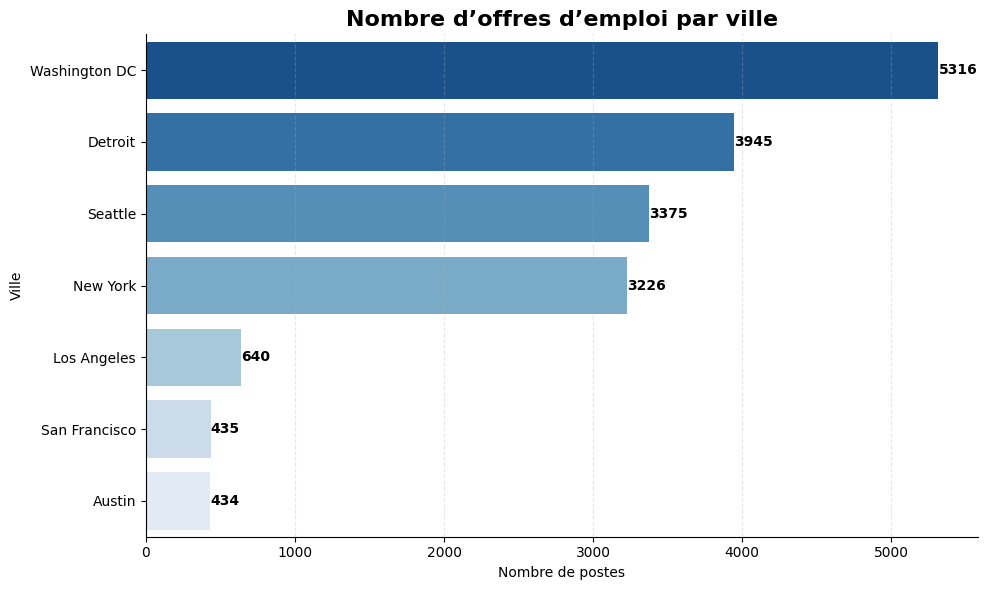

In [34]:


# Chargement des résultats (depuis ton Excel ou un DataFrame intermédiaire)
df_loc = pd.read_excel("../Data/External/Api/job-postings.xlsx", sheet_name="jobs locations").sort_values(by="job post",ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_loc,
    x="job post",
    y="Location",
    palette="Blues_r"
)

# Labels
for i, v in enumerate(df_loc["job post"]):
    ax.text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.title("Nombre d’offres d’emploi par ville", fontsize=16, fontweight="bold")
plt.xlabel("Nombre de postes")
plt.ylabel("Ville")

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()

plt.savefig("../Reports/Figures/API/01_api_jobs_by_city.png", dpi=300, bbox_inches='tight')
plt.show()


## 8. Représentation graphique : Nombre d’offres par technologie

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8808\847292729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


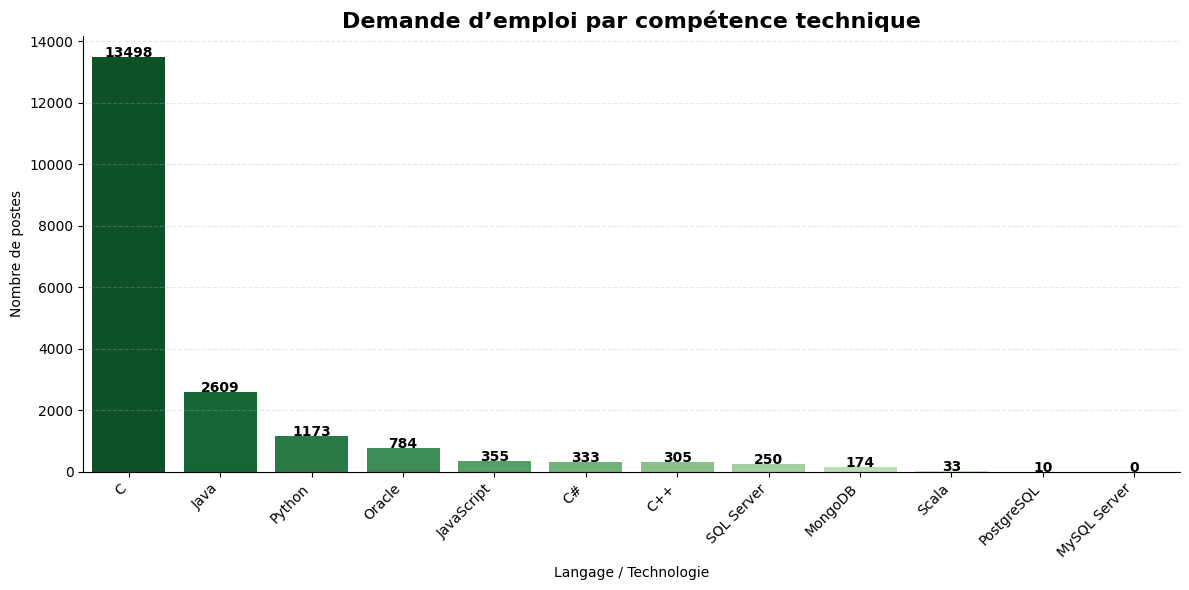

In [33]:
df_tech = pd.read_excel("../Data/External/Api/job-postings.xlsx", sheet_name="langages jobs").sort_values(by="nbr post",ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_tech,
    x="langage",
    y="nbr post",
    palette="Greens_r"
)

# Labels
for i, v in enumerate(df_tech["nbr post"]):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.title("Demande d’emploi par compétence technique", fontsize=16, fontweight="bold")
plt.xlabel("Langage / Technologie")
plt.ylabel("Nombre de postes")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()

plt.savefig("../Reports/Figures/API/01_api_jobs_by_skill.png", dpi=300, bbox_inches='tight')
plt.show()


## 9. Résumé

Ce module met en place un flux de collecte à partir d’une API REST locale.  
Il interroge le service de manière paramétrée, agrège les volumes par ville et par compétence, puis produit un fichier Excel prêt à être utilisé dans le rapport final pour la création de graphiques.  
Ce bloc s’intègre comme une source additionnelle dans le pipeline global et démontre l’intégration de données issues d’un service API dans un livrable analytique structuré.
